In [340]:
import numpy as np
import pandas as pd

In [341]:
df=pd.read_csv('Processed Data.csv')
df

,spatial__geohash,StandardScaler__Temperature,remainder__timestamp,remainder__RoadType,remainder__NumberofLanes,remainder__LargeVehicles,remainder__hour_sin,remainder__hour_cos,remainder__traffic_phase,remainder__is_peakrush,remainder__hour_from_peak,demand
0,0.037875,0.495999,3.0,1,1,1,0.707107,0.707107,1,0,14.0,0.048804
1,0.208036,0.728631,3.0,1,3,0,0.707107,0.707107,1,0,14.0,0.118507
2,0.123521,0.646568,3.0,1,1,1,0.707107,0.707107,1,0,14.0,0.027132
3,0.015368,0.495999,3.0,1,1,1,0.707107,0.707107,1,0,14.0,0.003272
4,0.031898,0.407346,3.0,1,1,1,0.707107,0.707107,1,0,14.0,0.010819
...,...,...,...,...,...,...,...,...,...,...,...,...
77294,0.027002,0.418392,5.0,1,1,1,0.965926,0.258819,1,0,12.0,0.067203
77295,0.141181,0.469251,5.0,1,3,0,0.965926,0.258819,1,0,12.0,0.022859
77296,0.115895,0.547806,5.0,1,3,0,0.965926,0.258819,1,0,12.0,0.141342
77297,0.077496,0.593624,5.0,1,1,1,0.965926,0.258819,1,0,12.0,0.087574


In [342]:
x=df.drop('demand',axis=1)
y=df['demand']

<Axes: xlabel='demand', ylabel='Count'>

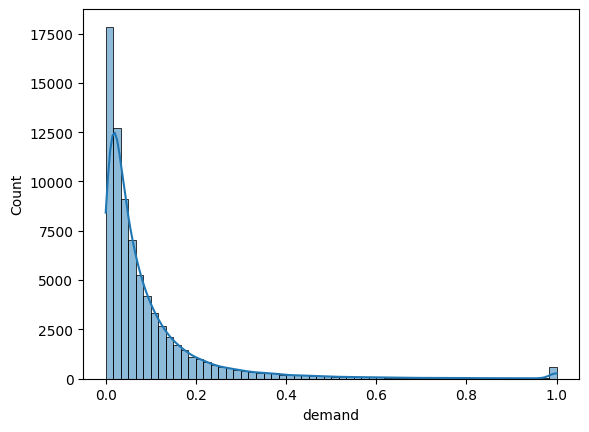

In [343]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(y,kde=True,bins=60)

In [344]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [345]:
from catboost import CatBoostRegressor
model=CatBoostRegressor()
model.fit(x_train,y_train)

Learning rate set to 0.07856
0:	learn: 0.1327394	total: 2.76ms	remaining: 2.76s
1:	learn: 0.1241397	total: 4.71ms	remaining: 2.35s
2:	learn: 0.1162362	total: 6.41ms	remaining: 2.13s
3:	learn: 0.1089398	total: 7.97ms	remaining: 1.99s
4:	learn: 0.1021987	total: 9.82ms	remaining: 1.96s
5:	learn: 0.0960550	total: 11.8ms	remaining: 1.96s
6:	learn: 0.0905721	total: 13.4ms	remaining: 1.9s
7:	learn: 0.0854802	total: 15ms	remaining: 1.86s
8:	learn: 0.0811184	total: 16.6ms	remaining: 1.83s
9:	learn: 0.0770138	total: 18.3ms	remaining: 1.81s
10:	learn: 0.0733382	total: 19.9ms	remaining: 1.79s
11:	learn: 0.0700392	total: 21.4ms	remaining: 1.76s
12:	learn: 0.0671749	total: 22.9ms	remaining: 1.74s
13:	learn: 0.0644999	total: 24.4ms	remaining: 1.72s
14:	learn: 0.0621652	total: 25.9ms	remaining: 1.7s
15:	learn: 0.0600916	total: 27.5ms	remaining: 1.69s
16:	learn: 0.0581469	total: 29.2ms	remaining: 1.69s
17:	learn: 0.0564741	total: 30.6ms	remaining: 1.67s
18:	learn: 0.0549174	total: 32ms	remaining: 1.65s

In [346]:
y_pred=model.predict(x_test)
y_pred

array([0.06693491, 0.07165125, 0.0314016 , ..., 0.03576103, 0.02292105,
       0.01175419])

In [347]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9144602782586989

In [375]:
model_submit=voting_model.fit(x,y)

0:	learn: 0.1409631	total: 13.7ms	remaining: 20.6s
1:	learn: 0.1397438	total: 18.9ms	remaining: 14.1s
2:	learn: 0.1385534	total: 25.2ms	remaining: 12.6s
3:	learn: 0.1373455	total: 35.5ms	remaining: 13.3s
4:	learn: 0.1361676	total: 70.7ms	remaining: 21.1s
5:	learn: 0.1350181	total: 87.4ms	remaining: 21.8s
6:	learn: 0.1338711	total: 97.8ms	remaining: 20.9s
7:	learn: 0.1327247	total: 105ms	remaining: 19.6s
8:	learn: 0.1315935	total: 110ms	remaining: 18.3s
9:	learn: 0.1304756	total: 116ms	remaining: 17.3s
10:	learn: 0.1293679	total: 121ms	remaining: 16.4s
11:	learn: 0.1282610	total: 127ms	remaining: 15.7s
12:	learn: 0.1271739	total: 131ms	remaining: 15s
13:	learn: 0.1261012	total: 136ms	remaining: 14.5s
14:	learn: 0.1250278	total: 141ms	remaining: 14s
15:	learn: 0.1239805	total: 145ms	remaining: 13.4s
16:	learn: 0.1229554	total: 149ms	remaining: 13s
17:	learn: 0.1219260	total: 154ms	remaining: 12.7s
18:	learn: 0.1209183	total: 159ms	remaining: 12.4s
19:	learn: 0.1199143	total: 164ms	remain

In [376]:
s=pd.read_csv('Processed Test Data.csv')
s

,spatial__geohash,StandardScaler__Temperature,remainder__timestamp,remainder__RoadType,remainder__NumberofLanes,remainder__LargeVehicles,remainder__hour_sin,remainder__hour_cos,remainder__traffic_phase,remainder__is_peakrush,remainder__hour_from_peak
0,0.040119,0.496822,2.25,1,1,1,0.555570,0.831470,0,1,14.75
1,0.031792,0.338859,2.25,1,1,1,0.555570,0.831470,0,1,14.75
2,0.029433,0.589577,2.25,1,3,0,0.555570,0.831470,0,1,14.75
3,0.040028,0.496822,2.25,1,2,1,0.555570,0.831470,0,1,14.75
4,0.054634,0.525448,2.25,1,1,1,0.555570,0.831470,0,1,14.75
...,...,...,...,...,...,...,...,...,...,...,...
41773,0.138812,0.546384,13.75,2,1,1,-0.442289,-0.896873,0,1,3.25
41774,0.113154,0.406268,13.75,1,2,1,-0.442289,-0.896873,0,1,3.25
41775,0.018080,0.445646,13.75,1,2,1,-0.442289,-0.896873,0,1,3.25
41776,0.075093,0.434365,13.75,1,2,1,-0.442289,-0.896873,0,1,3.25


In [377]:
o=model_submit.predict(s)

In [378]:
o=pd.DataFrame(o,columns=['demand'])

In [379]:
r=pd.read_csv('dataset copy/test.csv')

In [380]:
r=r['Index']

In [381]:
r=pd.DataFrame(r)

In [382]:
r['demand']=o
r

,Index,demand
0,0,0.040220
1,1,0.033322
2,2,0.028508
3,3,0.039677
4,4,0.053351
...,...,...
41773,41773,0.268198
41774,41774,0.143386
41775,41775,0.019178
41776,41776,0.097131


In [383]:
r.to_csv('submission.csv',index=False)

# More models

In [348]:
model2=CatBoostRegressor(depth=10,iterations=1500,learning_rate=0.01)
model2.fit(x_train,y_train)

y_pred2=model2.predict(x_test)
r2_score(y_test,y_pred2)

0:	learn: 0.1409551	total: 21.5ms	remaining: 32.2s
1:	learn: 0.1397414	total: 28.9ms	remaining: 21.7s
2:	learn: 0.1385483	total: 31.3ms	remaining: 15.6s
3:	learn: 0.1373432	total: 39.4ms	remaining: 14.7s
4:	learn: 0.1361663	total: 45.2ms	remaining: 13.5s
5:	learn: 0.1350213	total: 51.1ms	remaining: 12.7s
6:	learn: 0.1338867	total: 56.9ms	remaining: 12.1s
7:	learn: 0.1327424	total: 61.8ms	remaining: 11.5s
8:	learn: 0.1316117	total: 65.1ms	remaining: 10.8s
9:	learn: 0.1304971	total: 69.8ms	remaining: 10.4s
10:	learn: 0.1294049	total: 74.5ms	remaining: 10.1s
11:	learn: 0.1283124	total: 79.1ms	remaining: 9.8s
12:	learn: 0.1272275	total: 83.5ms	remaining: 9.55s
13:	learn: 0.1261568	total: 87.6ms	remaining: 9.3s
14:	learn: 0.1250853	total: 91.9ms	remaining: 9.09s
15:	learn: 0.1240394	total: 95ms	remaining: 8.81s
16:	learn: 0.1230209	total: 99.4ms	remaining: 8.68s
17:	learn: 0.1219941	total: 104ms	remaining: 8.52s
18:	learn: 0.1209912	total: 108ms	remaining: 8.42s
19:	learn: 0.1200050	total: 

0.9157678284690735

In [349]:
from sklearn.ensemble import RandomForestRegressor
model3=RandomForestRegressor(n_estimators=500,random_state=42,max_depth=20,min_samples_split=5,min_samples_leaf=3)
model3.fit(x_train,y_train)

y_pred3=model3.predict(x_test)
r2_score(y_test,y_pred3)

0.9193509161350362

In [350]:
from xgboost import XGBRegressor
model4=XGBRegressor(n_estimators=500,learning_rate=0.01,max_depth=10,subsample=0.8,colsample_bytree=0.8,random_state=42)
model4.fit(x_train,y_train) 

y_pred4=model4.predict(x_test)
r2_score(y_test,y_pred4)

0.9118219948534078

In [370]:
from lightgbm import LGBMRegressor
model5=LGBMRegressor(n_estimators=2000,learning_rate=0.01,max_depth=10,subsample=0.8,colsample_bytree=0.5,random_state=42)
model5.fit(x_train,y_train)         
y_pred5=model5.predict(x_test)
r2_score(y_test,y_pred5)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 834
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 9
[LightGBM] [Info] Start training from score 0.093784


0.910160250802627

In [374]:
from sklearn.ensemble import VotingRegressor
voting_model=VotingRegressor(estimators=[('catboost',model2),('randomforest',model3)],weights=[0.95,0.65])
voting_model.fit(x_train,y_train)
y_pred_voting=voting_model.predict(x_test)
r2_score(y_test,y_pred_voting)

0:	learn: 0.1409551	total: 4.8ms	remaining: 7.19s
1:	learn: 0.1397414	total: 9.77ms	remaining: 7.32s
2:	learn: 0.1385483	total: 12.3ms	remaining: 6.15s
3:	learn: 0.1373432	total: 16.8ms	remaining: 6.28s
4:	learn: 0.1361663	total: 21.3ms	remaining: 6.37s
5:	learn: 0.1350213	total: 25.7ms	remaining: 6.39s
6:	learn: 0.1338867	total: 30.3ms	remaining: 6.47s
7:	learn: 0.1327424	total: 34.6ms	remaining: 6.45s
8:	learn: 0.1316117	total: 37.8ms	remaining: 6.27s
9:	learn: 0.1304971	total: 42.3ms	remaining: 6.3s
10:	learn: 0.1294049	total: 46.6ms	remaining: 6.31s
11:	learn: 0.1283124	total: 50.8ms	remaining: 6.3s
12:	learn: 0.1272275	total: 55.7ms	remaining: 6.38s
13:	learn: 0.1261568	total: 60ms	remaining: 6.36s
14:	learn: 0.1250853	total: 64.3ms	remaining: 6.37s
15:	learn: 0.1240394	total: 67.4ms	remaining: 6.25s
16:	learn: 0.1230209	total: 72.1ms	remaining: 6.29s
17:	learn: 0.1219941	total: 76.1ms	remaining: 6.27s
18:	learn: 0.1209912	total: 80.8ms	remaining: 6.29s
19:	learn: 0.1200050	total:

0.9193041925820185

In [387]:
importance=model2.get_feature_importance()
pd.DataFrame({'feature':x.columns,'importance':importance}).sort_values(by='importance',ascending=False)

,feature,importance
3,remainder__RoadType,44.663826
0,spatial__geohash,37.816473
7,remainder__hour_cos,7.791203
6,remainder__hour_sin,2.755836
2,remainder__timestamp,2.048685
1,StandardScaler__Temperature,1.726810
10,remainder__hour_from_peak,1.573773
4,remainder__NumberofLanes,1.496229
5,remainder__LargeVehicles,0.127165
8,remainder__traffic_phase,0.000000
